In [ ]:

%pip install pandas
%pip install seaborn
%pip install matplotlib
%pip install scipy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


^C
Note: you may need to restart the kernel to use updated packages.


   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   - -------------------------------------- 1.6/37.3 MB 7.5 MB/s eta 0:00:05
   --- ------------------------------------ 3.4/37.3 MB 8.1 MB/s eta 0:00:05
   ----- ---------------------------------- 5.5/37.3 MB 8.8 MB/s eta 0:00:04
   -------- ------------------------------- 7.9/37.3 MB 9.4 MB/s eta 0:00:04
   ----------- ---------------------------- 10.7/37.3 MB 10.2 MB/s eta 0:00:03
   ------------- -------------------------- 12.3/37.3 MB 9.9 MB/s eta 0:00:03
   -------------- ------------------------- 13.9/37.3 MB 9.3 MB/s eta 0:00:03
   ---------------- ----------------------- 15.5/37.3 MB 9.1 MB/s eta 0:00:03
   ------------------ --------------------- 17.6/37.3 MB 9.2 MB/s eta 0:00:03
   -------------------- ------------------- 19.1/37.3 MB 9.0 MB/s eta 0:00:03
   ----------------------- ---------------- 22.0/37.3 MB 9.3 MB/s eta 0:00:02
   --------------------------- ------------ 25.4/37.3 MB 9.8 MB/s eta 0:00:


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
df = pd.read_csv('Topic3_healthcare_analytics_dataset.csv')

def get_unique_values(df, column_name=None):
    """
    Returns unique values from a pandas DataFrame.
    
    Parameters:
    df (pandas.DataFrame): The dataset.
    column_name (str, optional): The specific column to check. 
                                 If None, checks all columns.
    """
    if column_name:
        # Get unique values for a single column
        unique_vals = df[column_name].unique()
        print(f"--- Unique values in '{column_name}' ({len(unique_vals)} total) ---")
        return unique_vals
    else:
        # Get unique values for all columns in the dataset
        unique_dict = {}
        print("--- Unique values for ALL columns ---")
        for col in df.columns:
            unique_dict[col] = df[col].unique()
            print(f"{col}: {len(unique_dict[col])} unique values")
        return unique_dict

# ==========================================
# Example usage with your data:
# ==========================================

# 1. Load your dataset (replace 'hospital_data.csv' with your actual file path)
# df = pd.read_csv('hospital_data.csv')

# 2. To list all the unique types of wards the patients are in:
# unique_wards = get_unique_values(df, 'Ward_Type')
# print(unique_wards)

# 3. To see unique values for EVERY column:
# all_unique_data = get_unique_values(df)

In [ ]:
Citycodes = get_unique_values(df, 'City_Code_Hospital')
print(Citycodes)

--- Unique values in 'City_Code_Hospital' (11 total) ---


In [3]:
import pandas as pd

# 1. Define explicit dictionaries to map the strings to numerical ranks
stay_mapping = {
    '0-10': 1, '11-20': 2, '21-30': 3, '31-40': 4, 
    '51-60': 6, '41-50': 5, '71-80': 8, '61-70': 7, 
    '81-90': 9, '91-100': 10, 'More than 100 Days': 11
}

age_mapping = {
    '0-10': 1, '11-20': 2, '21-30': 3, '31-40': 4, 
    '41-50': 5, '51-60': 6, '61-70': 7, '71-80': 8, 
    '81-90': 9, '91-100': 10
}

# 2. Create new columns in your dataframe for the ranked data
# Assuming your dataframe is called 'df'
df['Stay_Ranked'] = df['Stay'].map(stay_mapping)
df['Age_Ranked'] = df['Age'].map(age_mapping)

# 3. Calculate the Spearman Correlation
correlation = df['Stay_Ranked'].corr(df['Age_Ranked'], method='spearman')

print(f"The Spearman correlation between Age and Length of Stay is: {correlation:.4f}")

The Spearman correlation between Age and Length of Stay is: 0.0900


C:\Users\sss\AppData\Local\Temp\ipykernel_7420\3943460294.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stay_counts.index, y=stay_counts.values, palette="viridis")


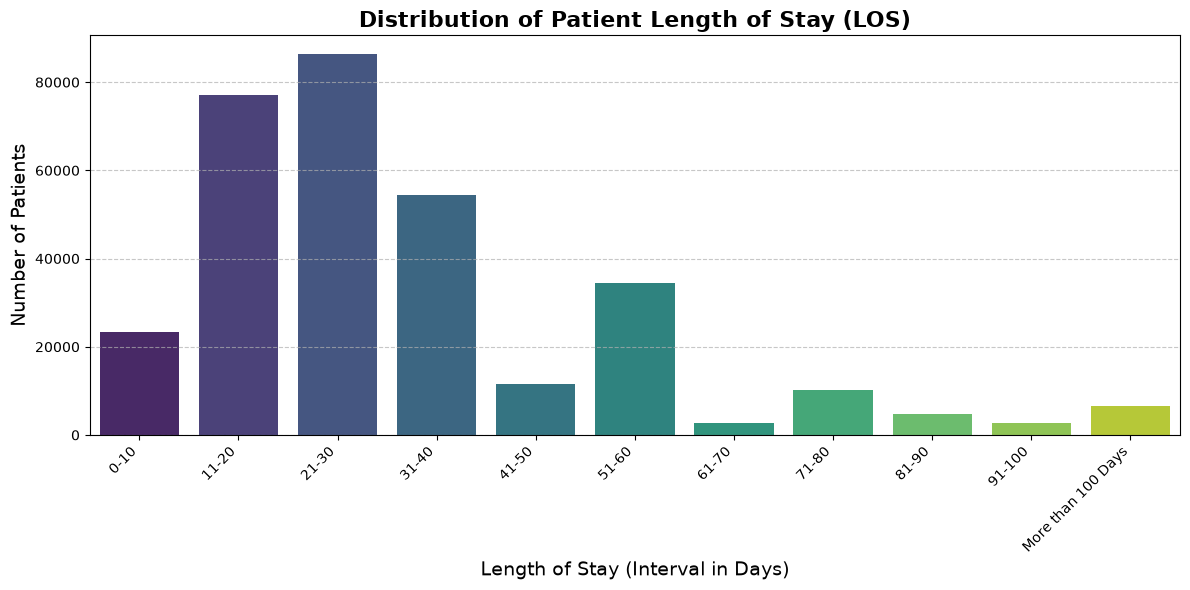

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the strictly logical order of your intervals
los_order = [
    '0-10', '11-20', '21-30', '31-40', '41-50', 
    '51-60', '61-70', '71-80', '81-90', '91-100', 
    'More than 100 Days'
]

# 2. Strip any hidden spaces (just in case!)
df['Stay'] = df['Stay'].astype(str).str.strip()

# 3. Convert the 'Stay' column into an Ordered Categorical data type
# This forces Pandas and Seaborn to respect our specific timeline
df['Stay'] = pd.Categorical(df['Stay'], categories=los_order, ordered=True)

# 4. Count the entries per interval and sort them by our custom index
stay_counts = df['Stay'].value_counts().sort_index()

# 5. Configure the plot aesthetics
plt.figure(figsize=(12, 6)) # Make it wide enough to fit the labels
sns.barplot(x=stay_counts.index, y=stay_counts.values, palette="viridis")

# 6. Add professional labels and titles for your university presentation
plt.title('Distribution of Patient Length of Stay (LOS)', fontsize=16, fontweight='bold')
plt.xlabel('Length of Stay (Interval in Days)', fontsize=14)
plt.ylabel('Number of Patients', fontsize=14)

# Rotate the X-axis labels 45 degrees so they don't overlap each other
plt.xticks(rotation=45, ha='right') 

# Add a subtle gridline on the Y-axis to make reading values easier
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout to ensure nothing gets cut off, then display
plt.tight_layout()
plt.show()

C:\Users\sss\AppData\Local\Temp\ipykernel_7420\2323109085.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_counts.index, y=age_counts.values, palette="magma")


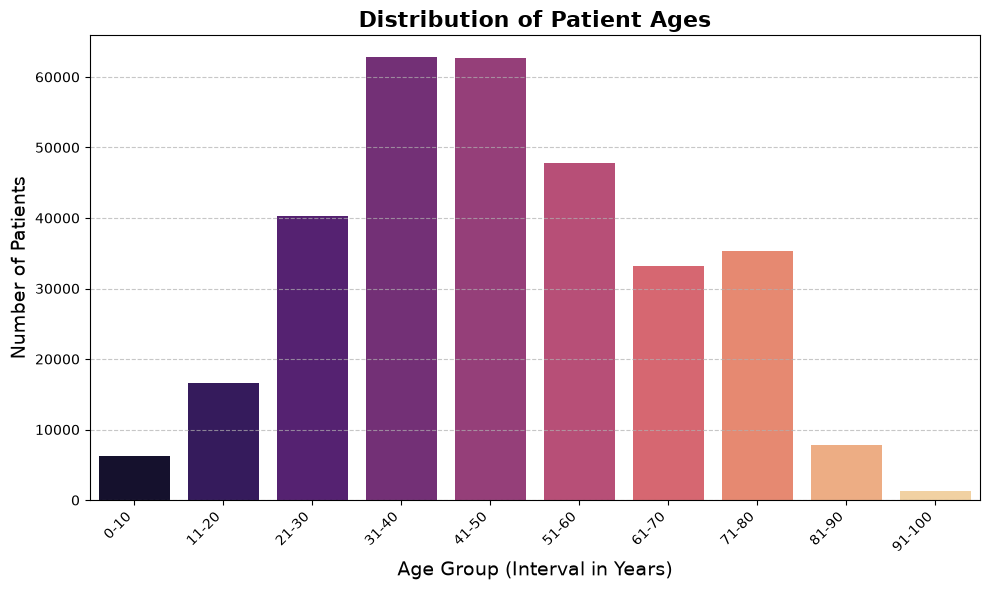

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the strictly logical order of your Age intervals
# (Notice we don't have a 'More than 100' bucket here based on your data)
age_order = [
    '0-10', '11-20', '21-30', '31-40', '41-50', 
    '51-60', '61-70', '71-80', '81-90', '91-100'
]

# 2. Strip any hidden spaces to prevent data-matching errors
df['Age'] = df['Age'].astype(str).str.strip()

# 3. Convert the 'Age' column into an Ordered Categorical data type
# This forces Pandas to plot '11-20' BEFORE '21-30', not alphabetically
df['Age'] = pd.Categorical(df['Age'], categories=age_order, ordered=True)

# 4. Count the entries per interval and sort them by our custom index
age_counts = df['Age'].value_counts().sort_index()

# 5. Configure the plot aesthetics
plt.figure(figsize=(10, 6)) # Slightly narrower is fine since the labels are shorter
sns.barplot(x=age_counts.index, y=age_counts.values, palette="magma")

# 6. Add professional labels and titles for your presentation
plt.title('Distribution of Patient Ages', fontsize=16, fontweight='bold')
plt.xlabel('Age Group (Interval in Years)', fontsize=14)
plt.ylabel('Number of Patients', fontsize=14)

# Rotate the X-axis labels slightly for a cleaner look
plt.xticks(rotation=45, ha='right') 

# Add a subtle gridline on the Y-axis to make reading values easier
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout to ensure nothing gets cut off, then display
plt.tight_layout()
plt.show()

In [12]:
#Hospital_region_code,Region Code of the Hospital
#City_Code_Patient,City Code for the patient

RegionCodes = get_unique_values(df, 'Hospital_region_code')
print(RegionCodes)
department = get_unique_values(df, 'Department')
print(department)
CityCodesPatient = get_unique_values(df, 'City_Code_Patient')
print(CityCodesPatient)
City_Code_Hospital=get_unique_values(df, 'City_Code_Hospital')
print(City_Code_Hospital)
type_of_admission = get_unique_values(df, 'Type of Admission')
print(type_of_admission)

Ward_Facility_Code = get_unique_values(df, 'Ward_Facility_Code')
print(Ward_Facility_Code)
Stay = get_unique_values(df, 'Stay')
print(Stay)
age = get_unique_values(df, 'Age')
print(age)
severity_of_illness = get_unique_values(df, 'Severity of Illness')
print(severity_of_illness)
vistories = get_unique_values(df, 'Visitors with Patient')
print(vistories)
admission_deposit = get_unique_values(df, 'Admission_Deposit')
print(admission_deposit)
type_of_admission = get_unique_values(df, 'Type of Admission')
print(type_of_admission)


--- Unique values in 'Hospital_region_code' (3 total) ---
<StringArray>
['Z', 'X', 'Y']
Length: 3, dtype: str
--- Unique values in 'Department' (5 total) ---
<StringArray>
['radiotherapy', 'anesthesia', 'gynecology', 'TB & Chest disease', 'surgery']
Length: 5, dtype: str
--- Unique values in 'City_Code_Patient' (37 total) ---
[ 7.  8.  2.  5.  6.  3.  4.  1.  9. 14. 25. 15. 12. 10. 28. 24. 23. 20.
 11. 13. 21. 18. 16. 26. 27. 22. 19. 31. 34. 32. 30. 29. 37. 33. 35. 36.
 38.]
--- Unique values in 'City_Code_Hospital' (11 total) ---
[ 3  5  1  2  6  9 10  4 11  7 13]
--- Unique values in 'Type of Admission' (3 total) ---
<StringArray>
['Emergency', 'Trauma', 'Urgent']
Length: 3, dtype: str
--- Unique values in 'Ward_Facility_Code' (6 total) ---
<StringArray>
['F', 'E', 'D', 'B', 'A', 'C']
Length: 6, dtype: str
--- Unique values in 'Stay' (11 total) ---
<StringArray>
[              '0-10',              '41-50',              '31-40',
              '11-20',              '51-60',            

In [13]:
age = get_unique_values(df, 'Age')
print(age)

--- Unique values in 'Age' (10 total) ---
<StringArray>
[ '51-60',  '71-80',  '31-40',  '41-50',  '81-90',  '61-70',  '21-30',
  '11-20',   '0-10', '91-100']
Length: 10, dtype: str


In [15]:
import pandas as pd

def count_unique_hospitals_per_city(df, city_col='City_Code_Hospital', hospital_col='Hospital_code'):
    """
    Groups a dataframe by city code and counts the number of unique hospitals.
    
    Parameters:
    df (pd.DataFrame): Your main hospital dataset.
    city_col (str): The exact name of the city code column.
    hospital_col (str): The exact name of the hospital ID column.
    
    Returns:
    pd.DataFrame: A new dataframe with the city codes and their unique hospital counts.
    """
    
    # 1. Group by the city code and count unique hospital IDs
    grouped_df = df.groupby(city_col)[hospital_col].nunique().reset_index()
    
    # 2. Rename the aggregated column for absolute clarity
    grouped_df.rename(columns={hospital_col: 'Unique_Hospital_Count'}, inplace=True)
    
    # 3. Sort from highest number of hospitals to lowest for easier reading
    grouped_df = grouped_df.sort_values(by='Unique_Hospital_Count', ascending=False).reset_index(drop=True)
    
    return grouped_df
print(count_unique_hospitals_per_city(df))

# ==========================================
# Example Usage:
# ==========================================
# Just pass your dataframe into the function, the column names are already set.
# city_distribution = count_unique_hospitals_per_city(df)
# print(city_distribution)

    City_Code_Hospital  Unique_Hospital_Count
0                    1                      6
1                    3                      6
2                    5                      4
3                    2                      3
4                    4                      3
5                    9                      3
6                    6                      2
7                    7                      2
8                   10                      1
9                   11                      1
10                  13                      1


--- Clinical Assumptions Check: Statistics ---
                    Total Patients  Median LOS  Std Deviation (Variance)
Department                                                              
anesthesia                   28589        25.5                     17.08
tb & chest disease            9336        25.5                     18.57
gynecology                  240993        25.5                     18.99
radiotherapy                 27228        25.5                     19.74
surgery                       1099        25.5                     21.43

Look for: Gynecology having a low Std Dev, and Surgery/TB having a high Std Dev.


C:\Users\sss\AppData\Local\Temp\ipykernel_4320\3771762854.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


TypeError: xticks(): Parameter 'labels' can't be set without setting 'ticks'

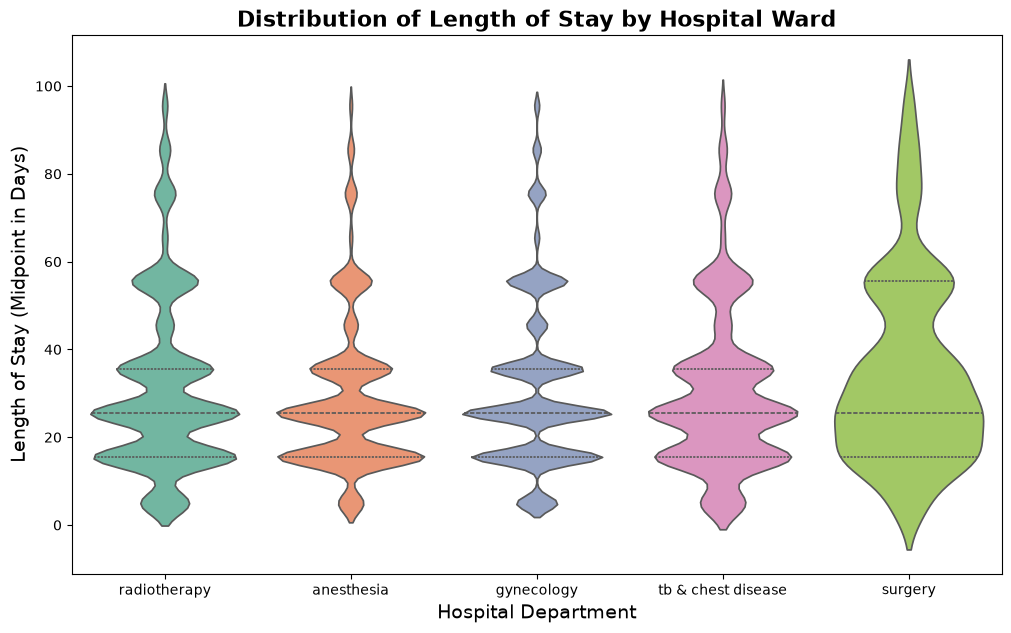

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. DATA PREP (Assuming 'df' is already loaded)
# ==========================================
# Update this variable to match your exact CSV column name for the wards
ward_col = 'Department' 

# Strip hidden spaces and standardize to lowercase to prevent matching errors
df['Stay'] = df['Stay'].astype(str).str.strip()
df[ward_col] = df[ward_col].astype(str).str.strip().str.lower()

# Map the ordinal 'Stay' intervals to numerical midpoints (from our previous step)
stay_midpoints = {
    '0-10': 5.0, '11-20': 15.5, '21-30': 25.5, '31-40': 35.5, 
    '41-50': 45.5, '51-60': 55.5, '61-70': 65.5, '71-80': 75.5, 
    '81-90': 85.5, '91-100': 95.5, 'more than 100 days': 110.0 
}
df['Stay_Numeric'] = df['Stay'].map(stay_midpoints)

# Filter the dataframe to only look at the wards we discussed
wards_of_interest = ['gynecology', 'tb & chest disease', 'radiotherapy', 'surgery', 'anesthesia']
analysis_df = df[df[ward_col].isin(wards_of_interest)].dropna(subset=['Stay_Numeric'])

# ==========================================
# 2. STATISTICAL PROOF (The Math)
# ==========================================
print("--- Clinical Assumptions Check: Statistics ---")
# Group by the ward and calculate the median LOS and the Standard Deviation (variance)
ward_stats = analysis_df.groupby(ward_col)['Stay_Numeric'].agg(['count', 'median', 'std']).round(2)
ward_stats = ward_stats.rename(columns={'count': 'Total Patients', 'median': 'Median LOS', 'std': 'Std Deviation (Variance)'})

# Sort by standard deviation to clearly see which ward is the most chaotic
ward_stats = ward_stats.sort_values(by='Std Deviation (Variance)', ascending=True)
print(ward_stats)
print("\nLook for: Gynecology having a low Std Dev, and Surgery/TB having a high Std Dev.")

# ==========================================
# 3. VISUAL PROOF (The Graph)
# ==========================================
plt.figure(figsize=(12, 7))

# We use a Violin Plot here instead of a Boxplot because it shows SKEWNESS perfectly.
# Thicker areas mean more patients stayed for that specific amount of time.
sns.violinplot(
    data=analysis_df, 
    x=ward_col, 
    y='Stay_Numeric', 
    palette='Set2',
    inner='quartile' # Shows the median and quartile lines inside the violin
)

plt.title('Distribution of Length of Stay by Hospital Ward', fontsize=16, fontweight='bold')
plt.xlabel('Hospital Department', fontsize=14)
plt.ylabel('Length of Stay (Midpoint in Days)', fontsize=14)

# Formatting text to make it look professional
plt.xticks(labels=[text.title() for text in wards_of_interest], fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

--- Patient Chronicity Analysis ---
Spearman Correlation (Visits vs Avg LOS): nan
P-value: nan
Conclusion: No statistically significant relationship found.


C:\Users\sss\AppData\Local\Temp\ipykernel_4320\1967988071.py:49: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  patient_df['Visit_Category'] = pd.Categorical(patient_df['Visit_Category'], categories=visit_order, ordered=True)


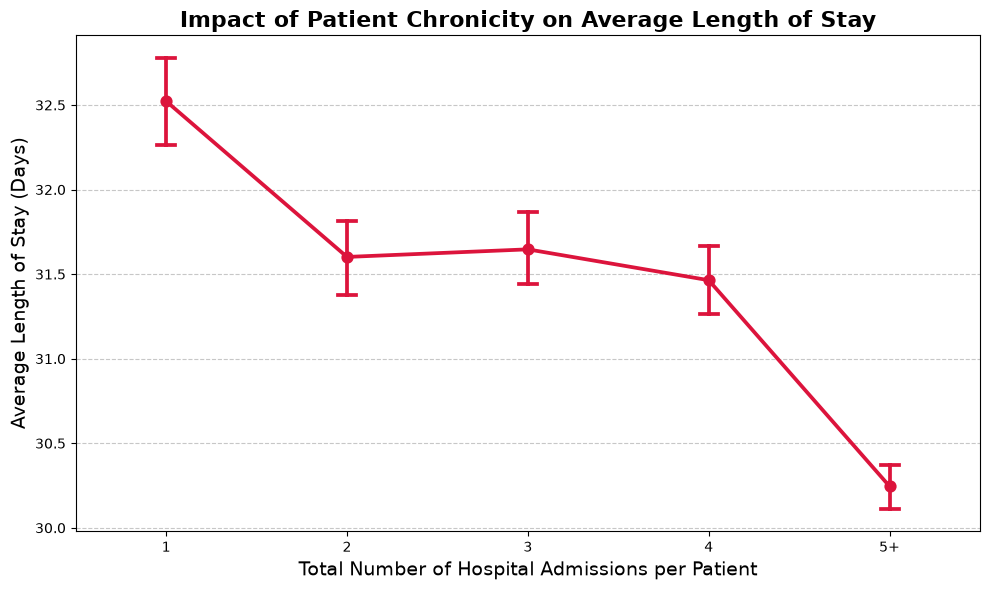

In [18]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. DATA PREP & PATIENT AGGREGATION
# ==========================================
# (Assuming your df already has the 'Stay_Numeric' column from our previous scripts)
patient_col = 'patientid' # Update this if your column is named differently!

# Group by the unique Patient ID
# We want two things: the COUNT of their visits, and the MEAN of their Length of Stay
patient_df = df.groupby(patient_col).agg(
    Total_Visits=('Stay_Numeric', 'count'),
    Average_LOS=('Stay_Numeric', 'mean')
).reset_index()

# ==========================================
# 2. STATISTICAL PROOF (Spearman Correlation)
# ==========================================
print("--- Patient Chronicity Analysis ---")

# We use Spearman because 'Total_Visits' is heavily right-skewed (most people have 1 visit)
corr, p_value = stats.spearmanr(patient_df['Total_Visits'], patient_df['Average_LOS'])

print(f"Spearman Correlation (Visits vs Avg LOS): {corr:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    if corr > 0:
        print("Conclusion: Statistically significant POSITIVE trend. Frequent patients stay longer.")
    elif corr < 0:
        print("Conclusion: Statistically significant NEGATIVE trend. Frequent patients have shorter stays.")
else:
    print("Conclusion: No statistically significant relationship found.")

# ==========================================
# 3. VISUALIZATION (Trend Analysis)
# ==========================================
# To make the graph readable, we will cap extreme outliers (e.g., a patient with 15 visits)
# into a single "5+ Visits" category.
patient_df['Visit_Category'] = patient_df['Total_Visits'].apply(
    lambda x: str(x) if x < 5 else '5+'
)

# Enforce a logical order for the plot
visit_order = ['1', '2', '3', '4', '5+']
patient_df['Visit_Category'] = pd.Categorical(patient_df['Visit_Category'], categories=visit_order, ordered=True)

plt.figure(figsize=(10, 6))

# A PointPlot is perfect here. It shows the mean (the dot) and the variance/confidence interval (the vertical line)
sns.pointplot(
    data=patient_df, 
    x='Visit_Category', 
    y='Average_LOS', 
    color='crimson',
    capsize=0.1 # Adds nice horizontal caps to the error bars
)

plt.title('Impact of Patient Chronicity on Average Length of Stay', fontsize=16, fontweight='bold')
plt.xlabel('Total Number of Hospital Admissions per Patient', fontsize=14)
plt.ylabel('Average Length of Stay (Days)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

--- Distribution of Patient Visits ---
   Number_of_Visits  Patient_Count
0                 1          19811
1                 2          18090
2                 3          15411
3                 4          12179
4                 5           9147
5                 6           6221
6                 7           4011
7                 8           2324
8                 9           1381
9                10            752


C:\Users\sss\AppData\Local\Temp\ipykernel_4320\1652778379.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


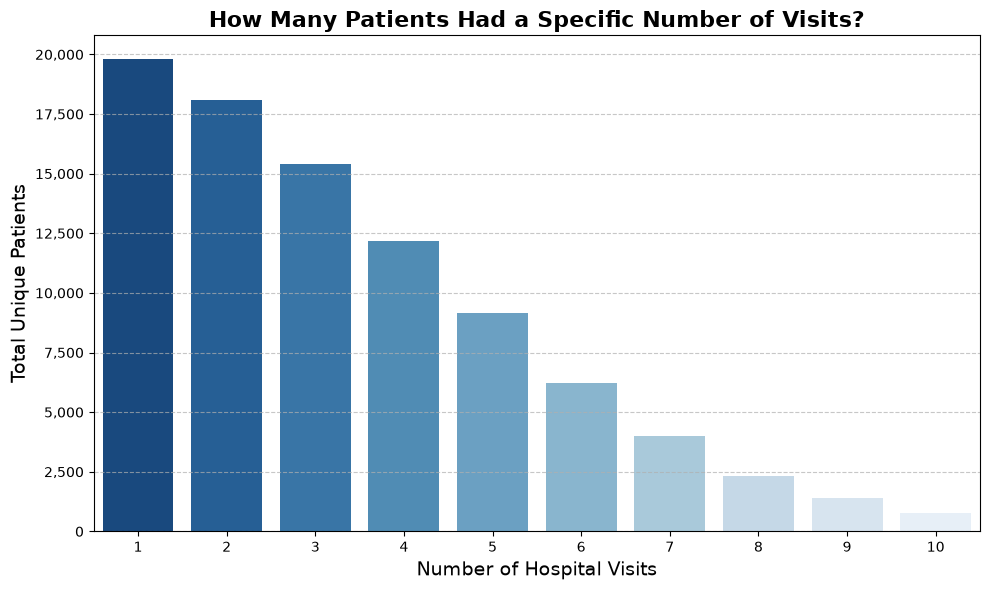

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. DATA PREP: THE DOUBLE AGGREGATION
# ==========================================
patient_col = 'patientid' # Update this if your column is named differently!

# Step 1: Find out how many times each unique patient visited
visits_per_patient = df.groupby(patient_col).size().reset_index(name='Total_Visits')

# Step 2: Count how many unique patients share the exact same number of total visits
visit_distribution = visits_per_patient['Total_Visits'].value_counts().reset_index()

# Rename columns so they make logical sense
visit_distribution.columns = ['Number_of_Visits', 'Patient_Count']

# Step 3: Sort the dataframe by the number of visits (1, 2, 3...) rather than by count
visit_distribution = visit_distribution.sort_values(by='Number_of_Visits').reset_index(drop=True)

# Print the mathematical breakdown to the console
print("--- Distribution of Patient Visits ---")
print(visit_distribution.head(10)) # Print the first 10 rows to see the bulk of the data

# ==========================================
# 2. VISUALIZATION
# ==========================================
plt.figure(figsize=(10, 6))

# We will limit the graph to the first 10 visit counts. 
# If a single patient visited 45 times, plotting it would squash the rest of your graph!
plot_data = visit_distribution.head(10)

sns.barplot(
    data=plot_data, 
    x='Number_of_Visits', 
    y='Patient_Count', 
    palette='Blues_r' # Using a blue gradient to differentiate from previous charts
)

plt.title('How Many Patients Had a Specific Number of Visits?', fontsize=16, fontweight='bold')
plt.xlabel('Number of Hospital Visits', fontsize=14)
plt.ylabel('Total Unique Patients', fontsize=14)

# Format the Y-axis to show commas (e.g., 100,000 instead of 100000) for professional readability
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()